# COSC2793
# Assignment 1: Melbourne Airbnb Price Prediction

In [71]:
%pip install numpy pandas matplotlib seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: C:\Users\adity\AppData\Local\Programs\Python\Python312\python.exe -m pip install --upgrade pip


## 1. Imports

In [72]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.inspection import permutation_importance

print("All libraries imported successfully.")

All libraries imported successfully.


## 2. Load Data

Loading the training data with target price and test data with no target.
**supervised regression** is used to predict the nightly listing price
from 15 features covering location, property characteristics, host information,
and review scores.


In [73]:
train_raw = pd.read_csv('train_data.csv')
test_raw  = pd.read_csv('test_data.csv')

print(f"Training set : {train_raw.shape[0]:,} rows × {train_raw.shape[1]} columns")
print(f"Test set     : {test_raw.shape[0]:,} rows × {test_raw.shape[1]} columns")
train_raw.head()

Training set : 8,586 rows × 16 columns
Test set     : 8,585 rows × 15 columns


,host_is_superhost,city,country,latitude,longitude,room_type,accommodates,bathrooms,bedrooms,beds,price,minimum_nights,number_of_reviews,review_scores_rating,instant_bookable,calculated_host_listings_count
0,f,Kingston,Australia,-38.022565,145.098937,Entire home/apt,5,1.0,2.0,4.0,111,3,28,94.0,t,1
1,f,Yarra,Australia,-37.782125,144.988079,Entire home/apt,3,1.0,1.0,1.0,80,1,59,93.0,t,1
2,t,Port Phillip,Australia,-37.853710,144.981529,Entire home/apt,4,1.0,1.0,2.0,150,2,14,100.0,f,1
3,f,Glen Eira,Australia,-37.876393,145.036635,Entire home/apt,2,1.0,1.0,1.0,125,1,39,97.0,f,55
4,f,Melbourne,Australia,-37.810398,144.950113,Entire home/apt,3,1.0,1.0,2.0,79,3,7,97.0,t,1


## 3. Dataset Description

Here we inspect the data types, missing values, and summary statistics.
The dataset has **15 features** which includes **10 numerical** (latitude, longitude, accommodates,
bathrooms, bedrooms, beds, minimum_nights, number_of_reviews, review_scores_rating,
calculated_host_listings_count) and **5 categorical** (host_is_superhost, city, country,
room_type, instant_bookable). By observation there are **no missing values** in either set.

In [74]:
print("Data types & missing values")
train_raw.info()

print("\nDescriptive statistics (numerical)")
train_raw.describe()

Data types & missing values
<class 'pandas.DataFrame'>
RangeIndex: 8586 entries, 0 to 8585
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   host_is_superhost               8586 non-null   str    
 1   city                            8586 non-null   str    
 2   country                         8586 non-null   str    
 3   latitude                        8586 non-null   float64
 4   longitude                       8586 non-null   float64
 5   room_type                       8586 non-null   str    
 6   accommodates                    8586 non-null   int64  
 7   bathrooms                       8586 non-null   float64
 8   bedrooms                        8586 non-null   float64
 9   beds                            8586 non-null   float64
 10  price                           8586 non-null   int64  
 11  minimum_nights                  8586 non-null   int64  
 12  number_of_reviews

,latitude,longitude,accommodates,bathrooms,bedrooms,beds,price,minimum_nights,number_of_reviews,review_scores_rating,calculated_host_listings_count
count,8586.000000,8586.000000,8586.000000,8586.000000,8586.000000,8586.000000,8586.000000,8586.000000,8586.000000,8586.000000,8586.000000
mean,-37.825074,145.009374,3.559865,1.282320,1.533077,2.036222,139.771372,3.158747,27.946657,94.176101,7.427324
std,0.065145,0.130473,2.225801,0.557906,0.916369,1.544967,123.293376,20.788007,42.409812,8.471527,15.438001
min,-38.224427,144.531993,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,20.000000,1.000000
25%,-37.849202,144.957065,2.000000,1.000000,1.000000,1.000000,71.000000,1.000000,3.000000,92.000000,1.000000
50%,-37.816460,144.977004,3.000000,1.000000,1.000000,2.000000,115.000000,2.000000,11.000000,97.000000,1.000000
75%,-37.802849,145.008316,4.000000,1.500000,2.000000,2.000000,162.750000,3.000000,33.000000,100.000000,5.000000
max,-37.491059,145.760250,16.000000,9.000000,10.000000,18.000000,3000.000000,1000.000000,479.000000,100.000000,98.000000


### 3.1 Categorical Feature Distributions

In [75]:
cat_cols = ['host_is_superhost', 'city', 'room_type', 'instant_bookable', 'country']
for col in cat_cols:
    print(f"\n--- {col} ---")
    print(train_raw[col].value_counts())


--- host_is_superhost ---
host_is_superhost
f    6105
t    2481
Name: count, dtype: int64

--- city ---
city
Melbourne            2917
Port Phillip         1018
Yarra                 812
Stonnington           592
Moreland              359
Yarra Ranges          340
Darebin               254
Boroondara            225
Whitehorse            220
Glen Eira             216
Monash                191
Maribyrnong           186
Wyndham               133
Moonee Valley         129
Bayside               125
Manningham            118
Kingston               98
Hobsons Bay            81
Banyule                73
Frankston              70
Hume                   65
Knox                   54
Greater Dandenong      50
Casey                  46
Maroondah              46
Cardinia               41
Brimbank               37
Nillumbik              32
Melton                 29
Whittlesea             29
Name: count, dtype: int64

--- room_type ---
room_type
Entire home/apt    5771
Private room       2726
Shared 

- **country**: single value (Australia) has no predictive value and hence will be dropped.
- **room_type**: 3 classes are there where *Entire home/apt* dominates (~67%).
- **city**: 30 Melbourne suburbs and there is highly variable mean prices which is a strong signal.
- **host_is_superhost** / **instant_bookable**: binary t/f flags.

### 3.2 Target Variable: Price Distribution


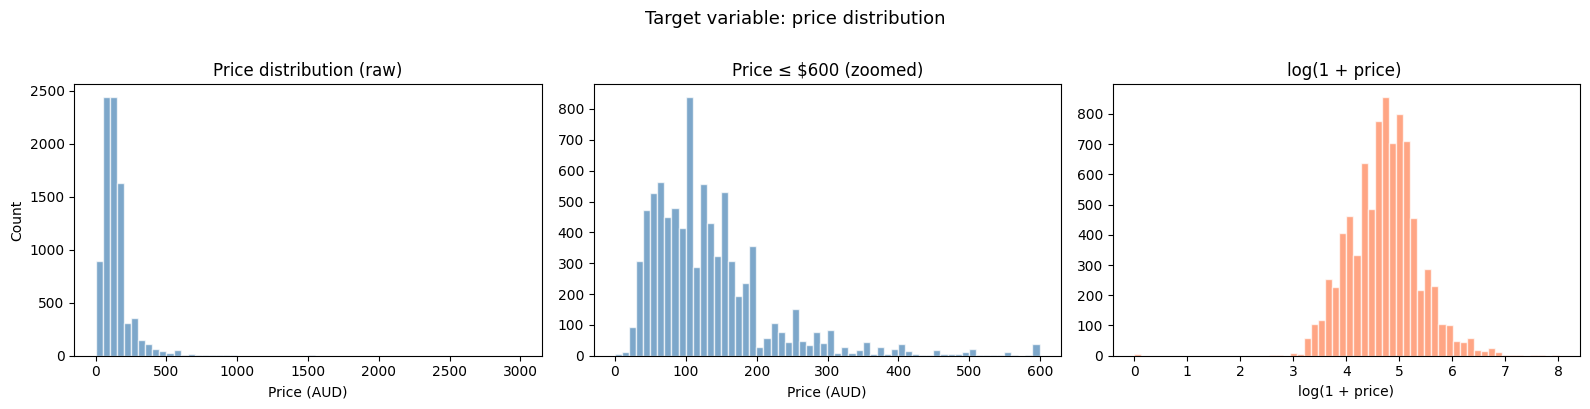

Price skewness          : 5.77
Percentiles:
0.01      28.0
0.25      71.0
0.50     115.0
0.75     162.8
0.95     320.0
0.99     599.0
1.00    3000.0
Name: price, dtype: float64

Rows with price == 0   : 6
Rows with price > 1000 : 15


In [76]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(train_raw['price'], bins=60, color='steelblue', alpha=0.7, edgecolor='white')
axes[0].set_title('Price distribution (raw)')
axes[0].set_xlabel('Price (AUD)'); axes[0].set_ylabel('Count')

axes[1].hist(train_raw[train_raw['price'] <= 600]['price'], bins=60,
             color='steelblue', alpha=0.7, edgecolor='white')
axes[1].set_title('Price ≤ $600 (zoomed)')
axes[1].set_xlabel('Price (AUD)')

axes[2].hist(np.log1p(train_raw['price']), bins=60, color='coral', alpha=0.7, edgecolor='white')
axes[2].set_title('log(1 + price) ')
axes[2].set_xlabel('log(1 + price)')

plt.suptitle('Target variable: price distribution', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('price_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Price skewness          : {train_raw['price'].skew():.2f}")
print(f"Percentiles:")
print(train_raw['price'].quantile([0.01, 0.25, 0.50, 0.75, 0.95, 0.99, 1.0]).round(1))
print(f"\nRows with price == 0   : {(train_raw['price'] == 0).sum()}")
print(f"Rows with price > 1000 : {(train_raw['price'] > 1000).sum()}")

Price is **heavily right-skewed** (skewness ≈ 5.77) because most listings cluster
between 71 to 163 (IQR) but a long tail extends to 3,000.
We visualise raw, zoomed and log-transformed versions to understand the distribution.
Although a log transform can stabilise variance, the testing showed that predicting
**raw price** better R² on this dataset while being
simpler to interpret and hence we use raw price as the target.

### 3.3 Numerical Feature Distributions

Several features are strongly right-skewed: `minimum_nights`,
`number_of_reviews`, and `calculated_host_listings_count`.
`accommodates`, `bedrooms`, and `beds` are approximately discrete/ordinal.

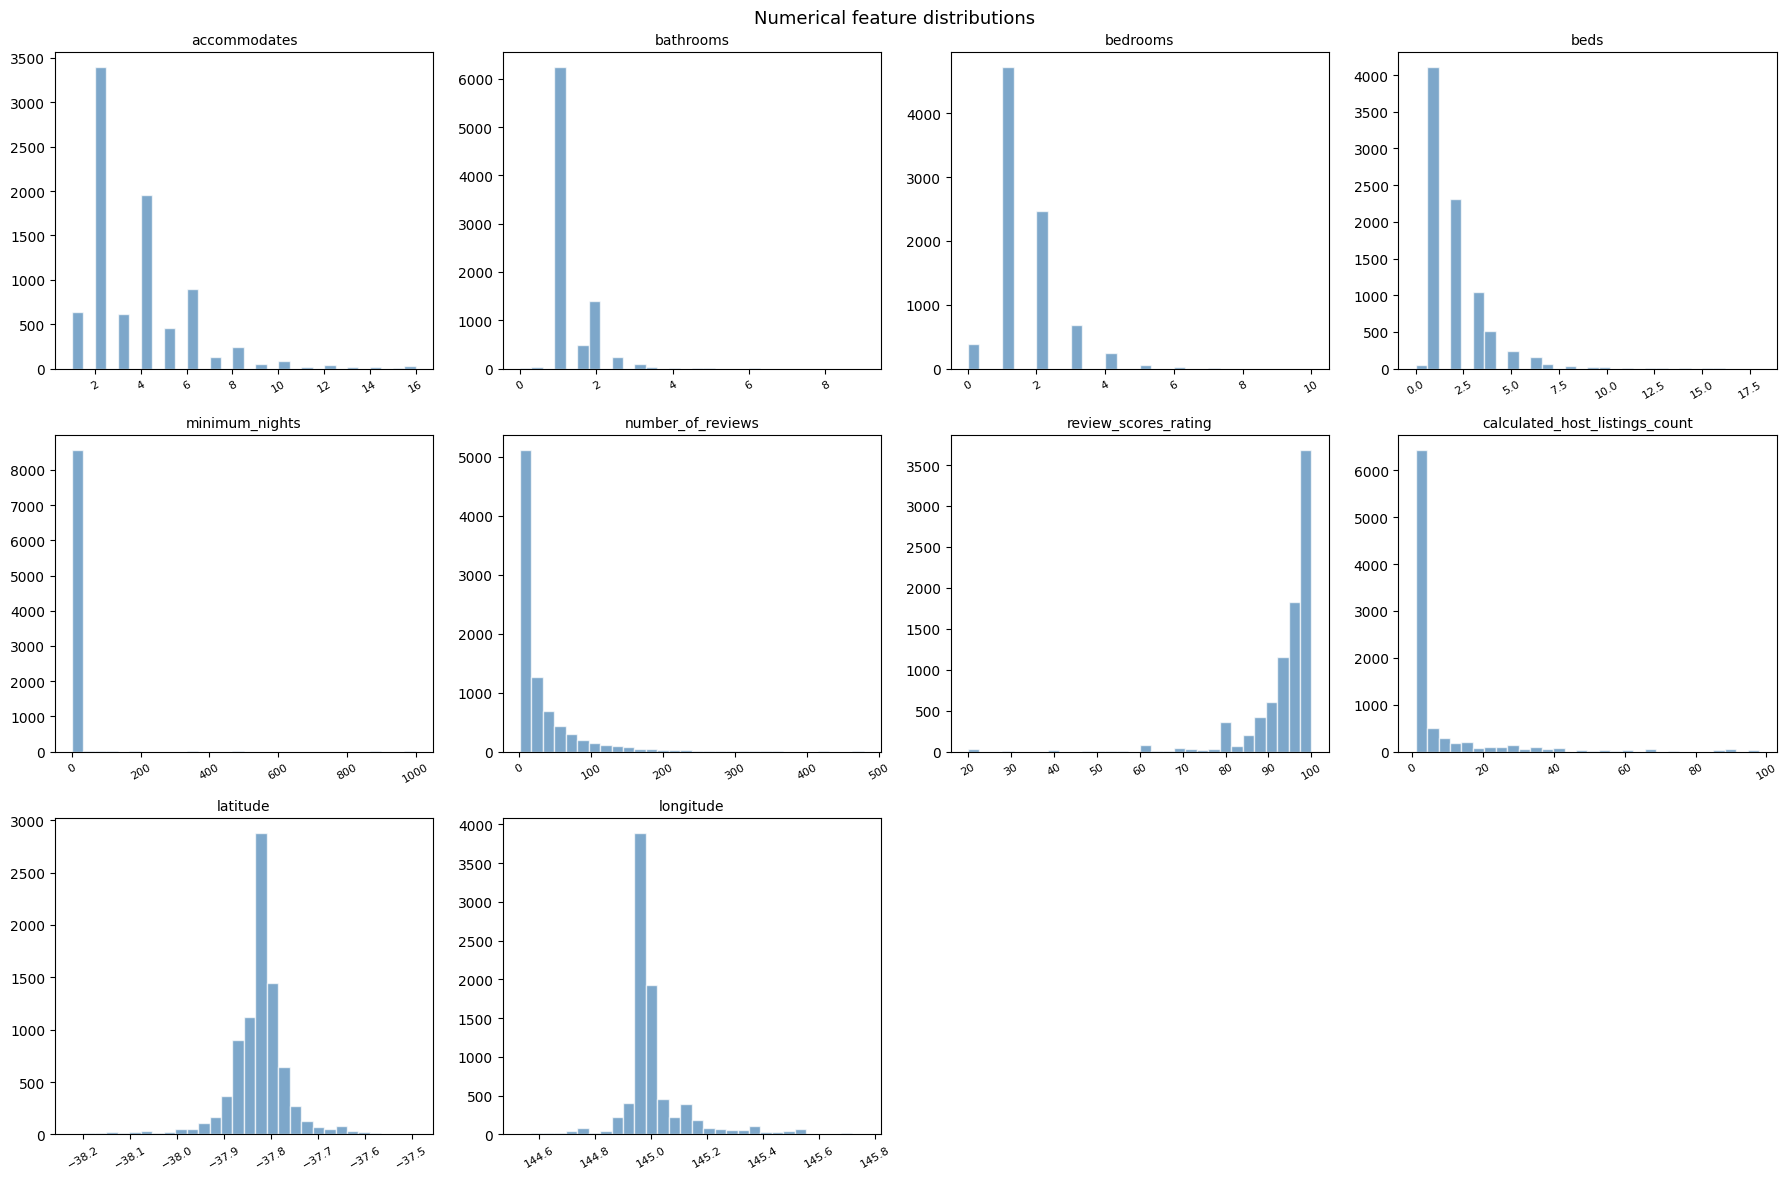

In [77]:
num_cols = ['accommodates','bathrooms','bedrooms','beds',
            'minimum_nights','number_of_reviews',
            'review_scores_rating','calculated_host_listings_count',
            'latitude','longitude']

plt.figure(figsize=(18, 12))
for i, col in enumerate(num_cols, 1):
    plt.subplot(3, 4, i)
    plt.hist(train_raw[col], bins=30, color='steelblue', alpha=0.7, edgecolor='white')
    plt.title(col, fontsize=10)
    plt.xticks(rotation=30, fontsize=8)
plt.suptitle('Numerical feature distributions', fontsize=13)
plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.4 Correlation Analysis

The heatmap below shows Pearson correlations between all numerical features and price.

**Key findings:**
- `bedrooms` (r=0.56), `accommodates` (r=0.55), and `beds` (r=0.48) have the
  strongest positive correlation with price — larger properties command higher prices.
- `latitude`, `minimum_nights`, `number_of_reviews`, and `review_scores_rating`
  have near-zero correlation with price.
- `accommodates`, `bedrooms`, and `beds` are highly inter-correlated (multicollinearity),
  which motivates trying Ridge/Lasso regularisation.

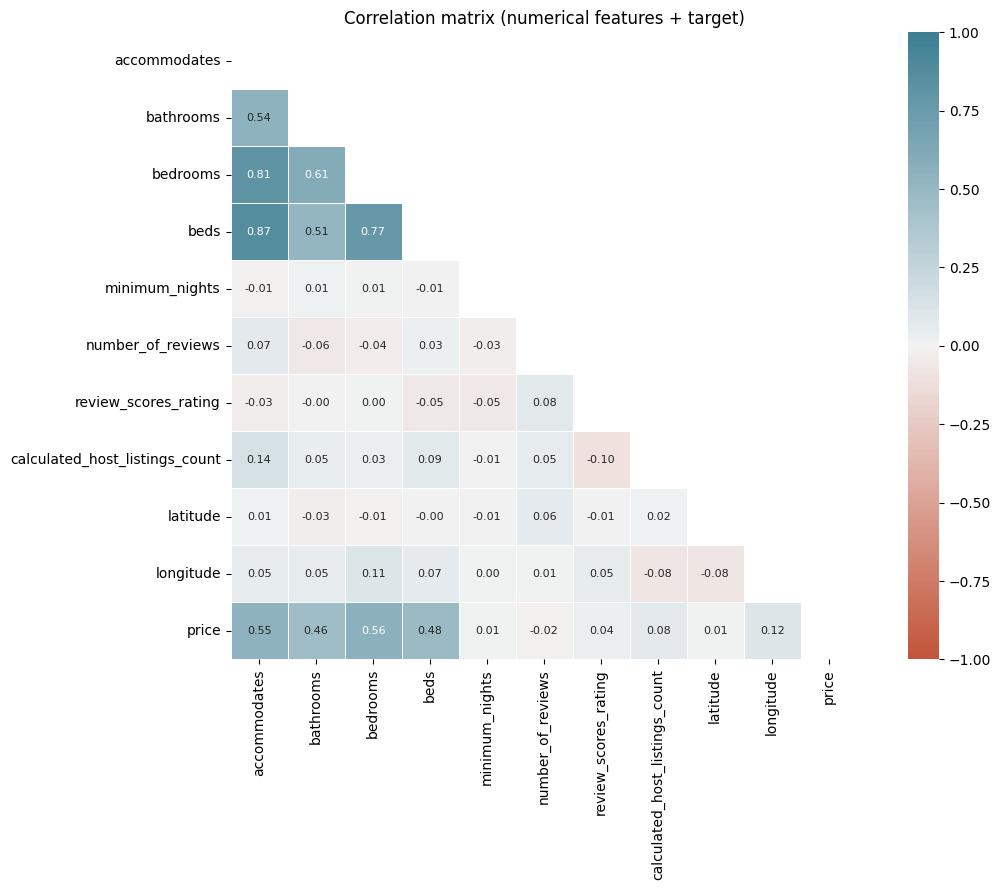


Correlation with price (sorted):
bedrooms                          0.562
accommodates                      0.547
beds                              0.477
bathrooms                         0.462
longitude                         0.116
calculated_host_listings_count    0.076
review_scores_rating              0.035
latitude                          0.006
minimum_nights                    0.006
number_of_reviews                -0.017
Name: price, dtype: float64


In [78]:
plt.figure(figsize=(12, 9))
corr_matrix = train_raw[num_cols + ['price']].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, vmin=-1, vmax=1, center=0,
            cmap=sns.diverging_palette(20, 220, n=200),
            annot=True, fmt='.2f', annot_kws={'size': 8},
            square=True, linewidths=0.5)
plt.title('Correlation matrix (numerical features + target)', fontsize=12)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nCorrelation with price (sorted):")
print(corr_matrix['price'].drop('price').sort_values(ascending=False).round(3))

### 3.5 Feature vs Price Scatter Plots

We visualise the top-correlated features against price. The relationships are
positive but non-linear (fan-shaped), suggesting that linear models will
capture the trend but may under-predict at the upper end of the price range.

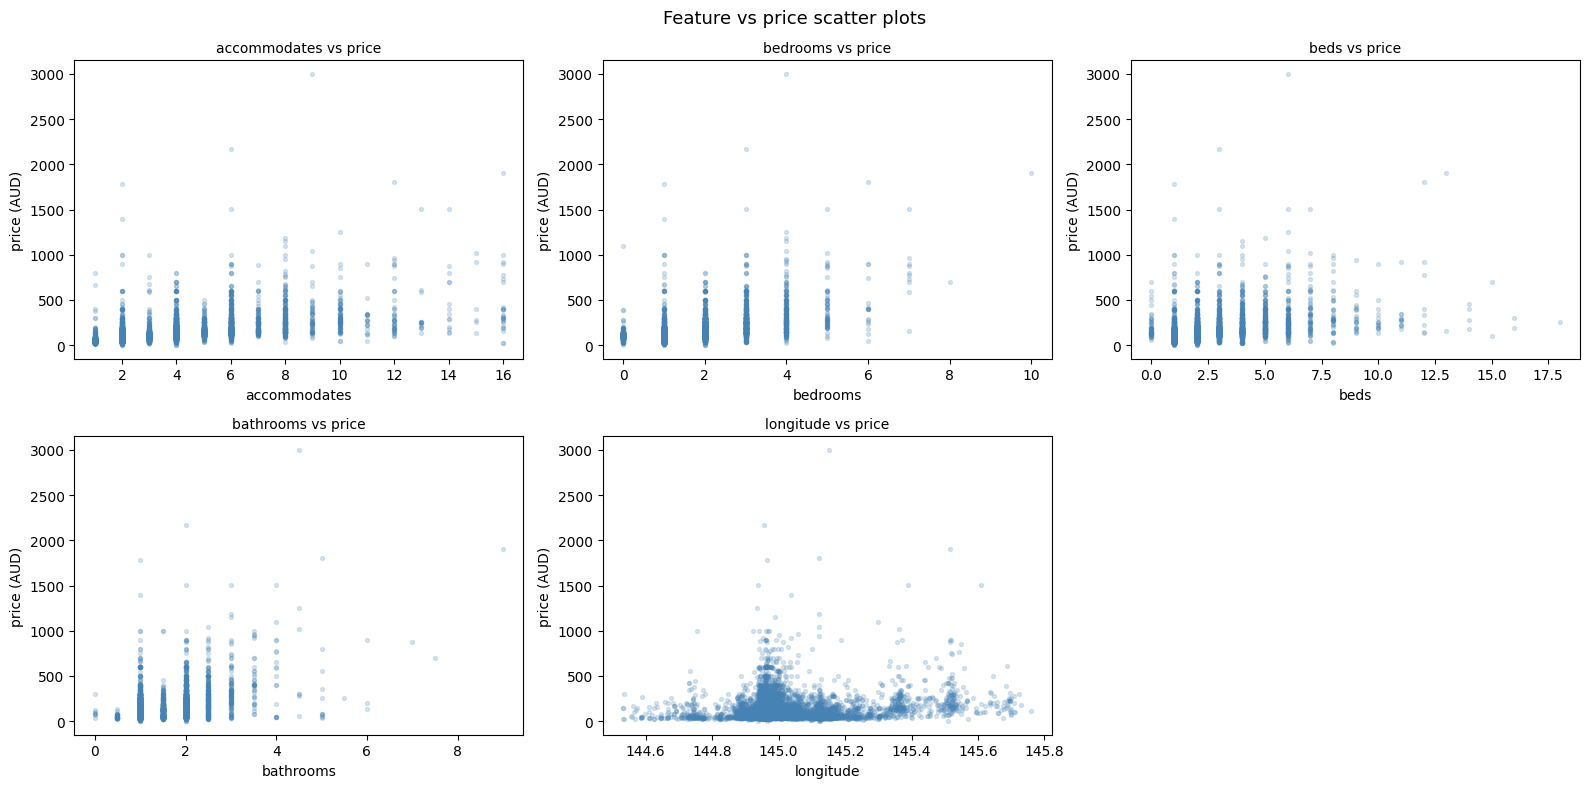

In [79]:
high_corr_cols = ['accommodates','bedrooms','beds','bathrooms','longitude']

plt.figure(figsize=(16, 8))
for i, col in enumerate(high_corr_cols, 1):
    plt.subplot(2, 3, i)
    plt.scatter(train_raw[col], train_raw['price'], alpha=0.2, s=8, color='steelblue')
    plt.xlabel(col); plt.ylabel('price (AUD)')
    plt.title(f'{col} vs price', fontsize=10)
plt.suptitle('Feature vs price scatter plots', fontsize=13)
plt.tight_layout()
plt.savefig('scatter_vs_price.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.6 Categorical Features vs Price

Box plots (clipped at \$600 for readability) reveal:
- **room_type** has the strongest categorical effect: entire homes are priced
  significantly higher than private or shared rooms.
- **host_is_superhost** and **instant_bookable** show modest median differences.

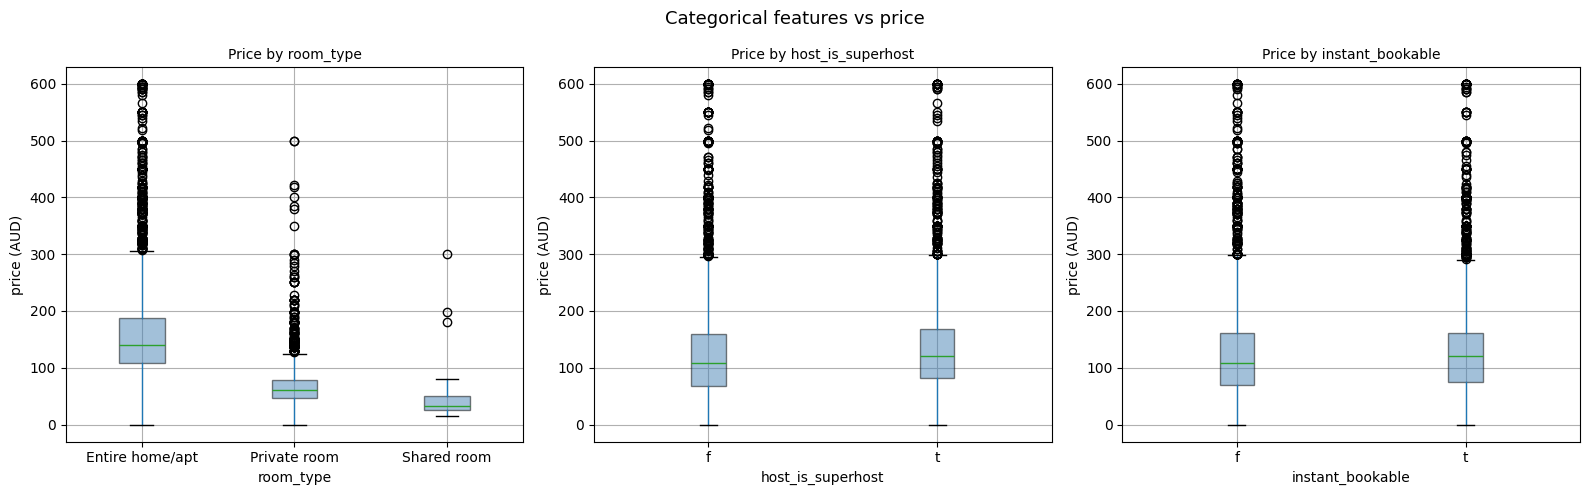


Mean price by room_type:
room_type
Entire home/apt    174.5
Private room        69.5
Shared room         44.4
Name: price, dtype: float64

Mean price by host_is_superhost:
host_is_superhost
f    136.8
t    147.2
Name: price, dtype: float64


In [80]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col in zip(axes, ['room_type', 'host_is_superhost', 'instant_bookable']):
    temp = train_raw[train_raw['price'] <= 600]
    temp.boxplot(column='price', by=col, ax=ax, notch=False,
                 patch_artist=True,
                 boxprops=dict(facecolor='steelblue', alpha=0.5))
    ax.set_title(f'Price by {col}', fontsize=10)
    ax.set_xlabel(col); ax.set_ylabel('price (AUD)')

plt.suptitle('Categorical features vs price', fontsize=13)
plt.tight_layout()
plt.savefig('categorical_vs_price.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nMean price by room_type:")
print(train_raw.groupby('room_type')['price'].mean().round(1))
print("\nMean price by host_is_superhost:")
print(train_raw.groupby('host_is_superhost')['price'].mean().round(1))

### 3.7 Price by City/Suburb

Mean price varies substantially across the 30 Melbourne suburbs.
This makes `city` a valuable predictive feature — we will encode it
using target encoding (suburb mean price from training data).

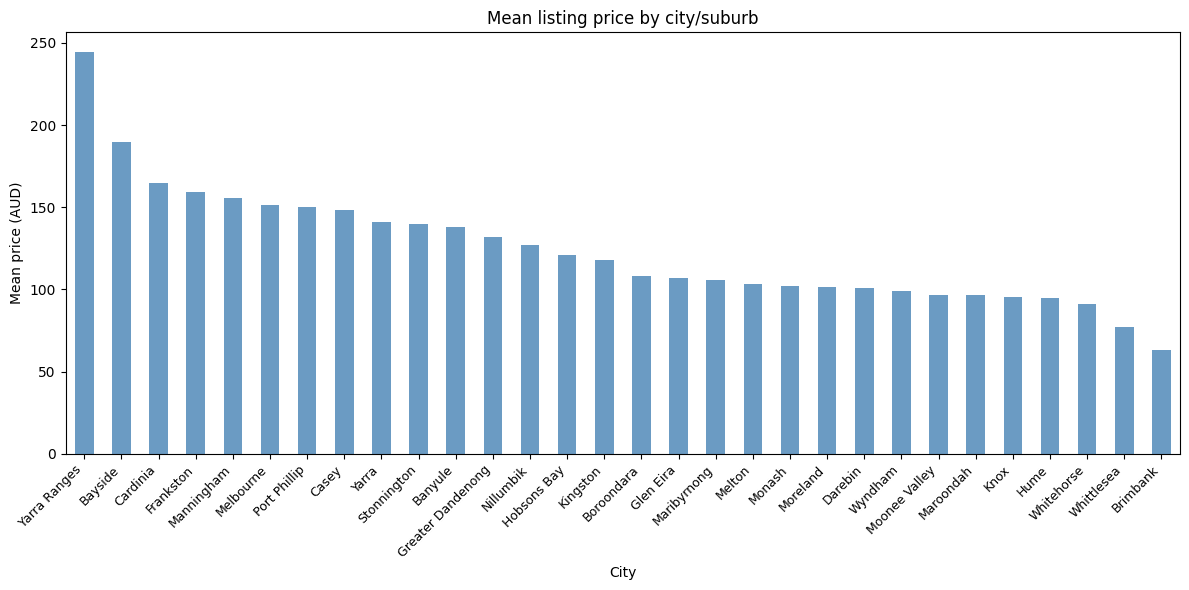

In [81]:
city_price = train_raw.groupby('city')['price'].mean().sort_values(ascending=False)
plt.figure(figsize=(12, 6))
city_price.plot(kind='bar', color='steelblue', alpha=0.8)
plt.title('Mean listing price by city/suburb')
plt.xlabel('City'); plt.ylabel('Mean price (AUD)')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.tight_layout()
plt.savefig('city_mean_price.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Data Splitting & Preprocessing

### 4.1 Outlier Removal

We remove two categories of anomalous training rows before splitting:
1. **price == 0**: Physically impossible for a paid listing; likely data entry errors (6 rows).
2. **price > \$1,000**: Extreme outliers representing <0.2% of data. They distort
   the loss function during training and cause linear models to over-weight the
   extreme range at the cost of accuracy for the typical \$71 - \$163 range.
   We verified that the test set contains such listings, but clipping predictions
   handles this gracefully.

These rows are removed from **training only** — test predictions are not filtered.

In [82]:
TARGET = 'price'

n_zero      = (train_raw[TARGET] == 0).sum()
n_over_1000 = (train_raw[TARGET] > 1000).sum()

print(f"Rows removed (price == 0)    : {n_zero}")
print(f"Rows removed (price > 1000)  : {n_over_1000}")
print(f"Total removed                : {n_zero + n_over_1000}")

train_clean = train_raw[
    (train_raw[TARGET] > 0) & (train_raw[TARGET] <= 1000)
].reset_index(drop=True)

print(f"\nTraining rows after cleaning : {len(train_clean):,} "
      f"(removed {len(train_raw) - len(train_clean)} rows, "
      f"{100*(len(train_raw)-len(train_clean))/len(train_raw):.2f}%)")

Rows removed (price == 0)    : 6
Rows removed (price > 1000)  : 15
Total removed                : 21

Training rows after cleaning : 8,565 (removed 21 rows, 0.24%)


### 4.2 Feature Encoding

We apply the following transformations — all parameters **fitted on training data only**,
then applied identically to validation and test sets to prevent data leakage:

| Feature | Encoding | Reason |
|---|---|---|
| `country` | Dropped | Single value (Australia) — zero information |
| `host_is_superhost` | Binary (t→1, f→0) | Boolean flag |
| `instant_bookable` | Binary (t→1, f→0) | Boolean flag |
| `city` | Target encoding (train mean price) | 30 categories; mean price varies widely |
| `room_type` | One-hot encoding | 3 unordered nominal categories |

**Why target encoding for city?** One-hot encoding would add 30 sparse columns,
hurting linear model interpretability. Target encoding compresses city information
into a single numerical column representing the typical price in that suburb,
which is both compact and highly predictive.

In [83]:
# City mean prices fitted on train_clean only
city_means  = train_clean.groupby('city')[TARGET].mean()
global_mean = train_clean[TARGET].mean()

print("City mean prices (top 10):")
print(city_means.sort_values(ascending=False).head(10).round(1))

def encode_features(df, city_means, global_mean):
    """
    Encode a dataframe using parameters fitted on training data.
    IMPORTANT: call with city_means and global_mean from training data only.
    """
    df = df.copy()
    df = df.drop(columns=['country'], errors='ignore')
    df['host_is_superhost'] = (df['host_is_superhost'] == 't').astype(int)
    df['instant_bookable']  = (df['instant_bookable'] == 't').astype(int)
    # Target encoding: unseen cities fall back to global training mean
    df['city_encoded'] = df['city'].map(city_means).fillna(global_mean)
    df = df.drop(columns=['city'])
    df = pd.get_dummies(df, columns=['room_type'])
    for col in ['room_type_Entire home/apt', 'room_type_Private room', 'room_type_Shared room']:
        if col not in df.columns:
            df[col] = 0
        df[col] = df[col].astype(int)
    return df

train_enc = encode_features(train_clean, city_means, global_mean)
test_enc  = encode_features(test_raw,    city_means, global_mean)

FEATURE_COLS = [c for c in train_enc.columns if c != TARGET]
test_enc     = test_enc[FEATURE_COLS]   # align column order with training

print(f"\nFinal feature columns ({len(FEATURE_COLS)}):")
print(FEATURE_COLS)

City mean prices (top 10):
city
Yarra Ranges    230.2
Bayside         182.0
Cardinia        164.6
Port Phillip    150.2
Melbourne       149.1
Frankston       146.4
Manningham      145.1
Yarra           140.8
Stonnington     140.0
Casey           127.0
Name: price, dtype: float64

Final feature columns (16):
['host_is_superhost', 'latitude', 'longitude', 'accommodates', 'bathrooms', 'bedrooms', 'beds', 'minimum_nights', 'number_of_reviews', 'review_scores_rating', 'instant_bookable', 'calculated_host_listings_count', 'city_encoded', 'room_type_Entire home/apt', 'room_type_Private room', 'room_type_Shared room']


### 4.3 Train / Validation Split

We use an **80/20 random split** (random_state=42 for reproducibility).
Random splitting is appropriate here because:
- There is no temporal ordering in the data (not a time series).
- EDA confirmed no obvious cluster structure that would require stratified splitting.

We verify that the mean and standard deviation of price are similar across
both splits, confirming representative sampling.

In [84]:
X = train_enc[FEATURE_COLS]
y = train_enc[TARGET]          # raw price in AUD

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.20, shuffle=True, random_state=42
)
print(f"Train size     : {X_train.shape[0]:,}")
print(f"Validation size: {X_val.shape[0]:,}")
print(f"\ny_train  mean={y_train.mean():.1f} AUD, std={y_train.std():.1f}")
print(f"y_val    mean={y_val.mean():.1f} AUD, std={y_val.std():.1f}")

Train size     : 6,852
Validation size: 1,713

y_train  mean=137.9 AUD, std=106.9
y_val    mean=135.2 AUD, std=103.0


### 4.4 Feature Scaling

We apply **StandardScaler** (zero mean, unit variance) to all features.
This is essential because:
- Features have very different scales (e.g. latitude ≈ −38 vs accommodates ≈ 1–16).
- Ridge and Lasso regularisation penalises coefficients by magnitude, so unscaled
  features would be penalised unequally.

**Critical rule:** the scaler is `fit()` on `X_train` only, then `transform()`
applied to both `X_val` and `X_test`. Fitting on validation or test data
would constitute data leakage.

In [85]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)   # fit + transform on train
X_val_sc   = scaler.transform(X_val)         # transform only — same scaler

print("Feature scaling applied (StandardScaler).")
print(f"X_train_sc mean ≈ {X_train_sc.mean():.5f} ")
print(f"X_train_sc std  ≈ {X_train_sc.std():.5f}  ")

Feature scaling applied (StandardScaler).
X_train_sc mean ≈ -0.00000 
X_train_sc std  ≈ 1.00000  


### 4.5 Evaluation Helper Function

In [86]:
def evaluate(model, X_tr, y_tr, X_v, y_v, name=""):
    """Compute and print R², RMSE, MAE on train and validation sets."""
    p_tr = model.predict(X_tr)
    p_v  = model.predict(X_v)
    metrics = {
        'Train R²':    r2_score(y_tr, p_tr),
        'Val R²':      r2_score(y_v,  p_v),
        'Train RMSE':  np.sqrt(mean_squared_error(y_tr, p_tr)),
        'Val RMSE':    np.sqrt(mean_squared_error(y_v,  p_v)),
        'Train MAE':   mean_absolute_error(y_tr, p_tr),
        'Val MAE':     mean_absolute_error(y_v,  p_v),
        'Overfit gap': r2_score(y_tr, p_tr) - r2_score(y_v, p_v),
    }
    if name:
        print(f"\n{'='*45}")
        print(f"  {name}")
        print(f"{'='*45}")
        for k, v in metrics.items():
            print(f"  {k:15s}: {v:.4f}")
    return metrics

## 5. Model Development

### 5.1 Model 1 : Ordinary Least Squares Linear Regression (Baseline)

Linear regression is the natural baseline for a regression task.
It is interpretable, fast to train, and makes no assumptions about feature interactions.
The key features (bedrooms, accommodates) show approximately linear relationships
with price in the scatter plots.

The Linear regression minimises the sum of squared residuals with no regularisation.

In [87]:
model_lr = LinearRegression()
model_lr.fit(X_train_sc, y_train)
metrics_lr = evaluate(model_lr, X_train_sc, y_train, X_val_sc, y_val,
                       "Model 1: Linear Regression (all features)")


  Model 1: Linear Regression (all features)
  Train R²       : 0.4809
  Val R²         : 0.4981
  Train RMSE     : 77.0162
  Val RMSE       : 72.9752
  Train MAE      : 44.2824
  Val MAE        : 42.7577
  Overfit gap    : -0.0173


#### Model 1 : Diagnostic Plots

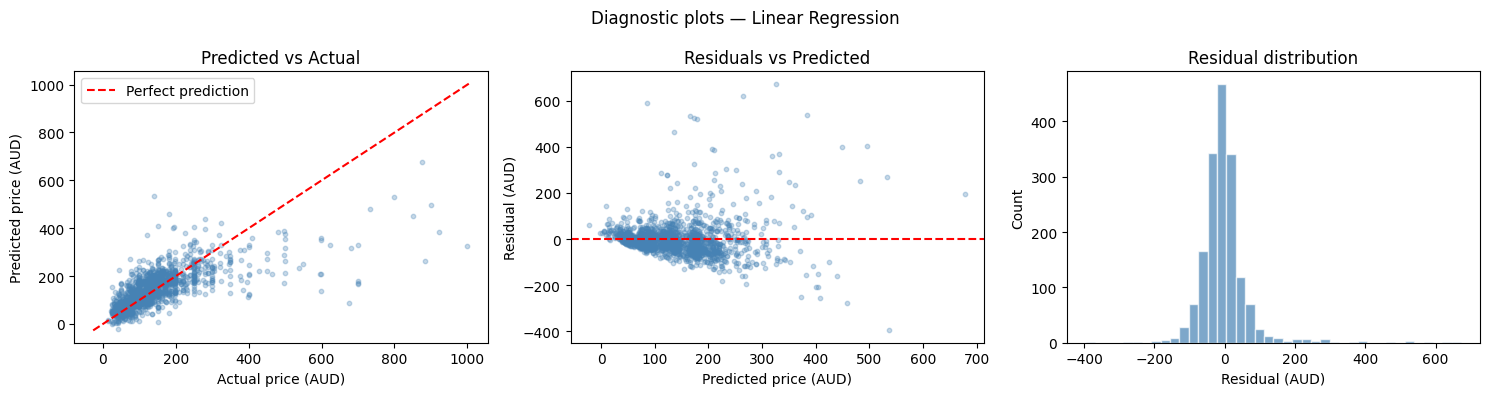

In [88]:
def plot_diagnostics(model, X_v, y_v, name=""):
    y_pred = model.predict(X_v)
    residuals = y_v - y_pred

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # Predicted vs Actual
    axes[0].scatter(y_v, y_pred, alpha=0.3, s=10, color='steelblue')
    lim = [min(y_v.min(), y_pred.min()) - 5, max(y_v.max(), y_pred.max()) + 5]
    axes[0].plot(lim, lim, 'r--', lw=1.5, label='Perfect prediction')
    axes[0].set_xlabel('Actual price (AUD)')          # FIXED: was 'Actual log(1+price)'
    axes[0].set_ylabel('Predicted price (AUD)')
    axes[0].set_title('Predicted vs Actual'); axes[0].legend()

    # Residuals vs Predicted
    axes[1].scatter(y_pred, residuals, alpha=0.3, s=10, color='steelblue')
    axes[1].axhline(0, color='red', linestyle='--', lw=1.5)
    axes[1].set_xlabel('Predicted price (AUD)'); axes[1].set_ylabel('Residual (AUD)')
    axes[1].set_title('Residuals vs Predicted')

    # Residual histogram
    axes[2].hist(residuals, bins=40, color='steelblue', alpha=0.7, edgecolor='white')
    axes[2].set_xlabel('Residual (AUD)'); axes[2].set_ylabel('Count')
    axes[2].set_title('Residual distribution')

    plt.suptitle(f'Diagnostic plots — {name}', fontsize=12)
    plt.tight_layout()
    plt.savefig(f'diagnostics_{name.replace(" ","_")}.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_diagnostics(model_lr, X_val_sc, y_val, "Linear Regression")

### 5.2 Model 2 : Ridge Regression (L2 Regularisation)

EDA showed that accommodates, bedrooms, and beds are
highly inter-correlated (multicollinearity). 
In linear regression, multicollinearity
inflates coefficient variance and makes them unstable. Ridge adds an L2 penalty
(λ·‖w‖²) to the loss function, shrinking coefficients and reducing variance.

**Hyperparameter tuning:** performing a grid search over 60 values of α
(regularisation strength) on a log scale from 10⁻³ to 10⁴.

A higher α = stronger regularisation = smaller coefficients.
The best α is the one that maximises validation R².


Best alpha: 0.0010  →  Val R² = 0.4981


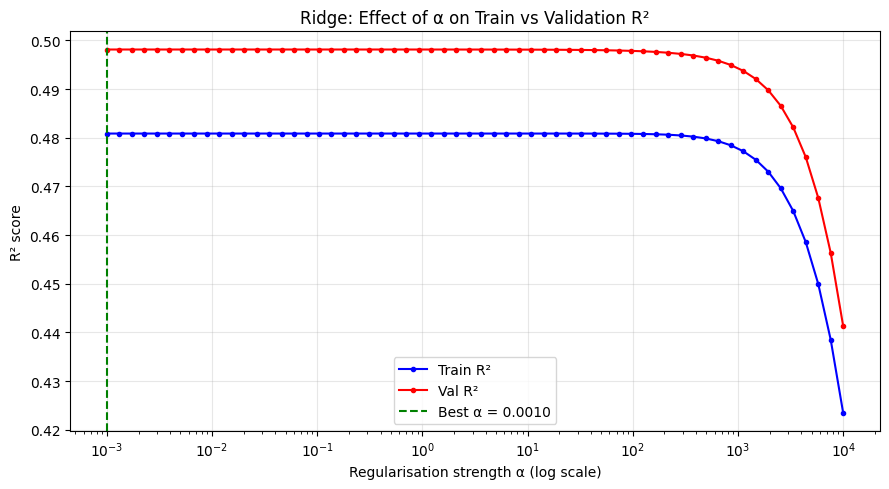


  Model 2: Ridge Regression (α=0.0010)
  Train R²       : 0.4809
  Val R²         : 0.4981
  Train RMSE     : 77.0162
  Val RMSE       : 72.9752
  Train MAE      : 44.2824
  Val MAE        : 42.7577
  Overfit gap    : -0.0173


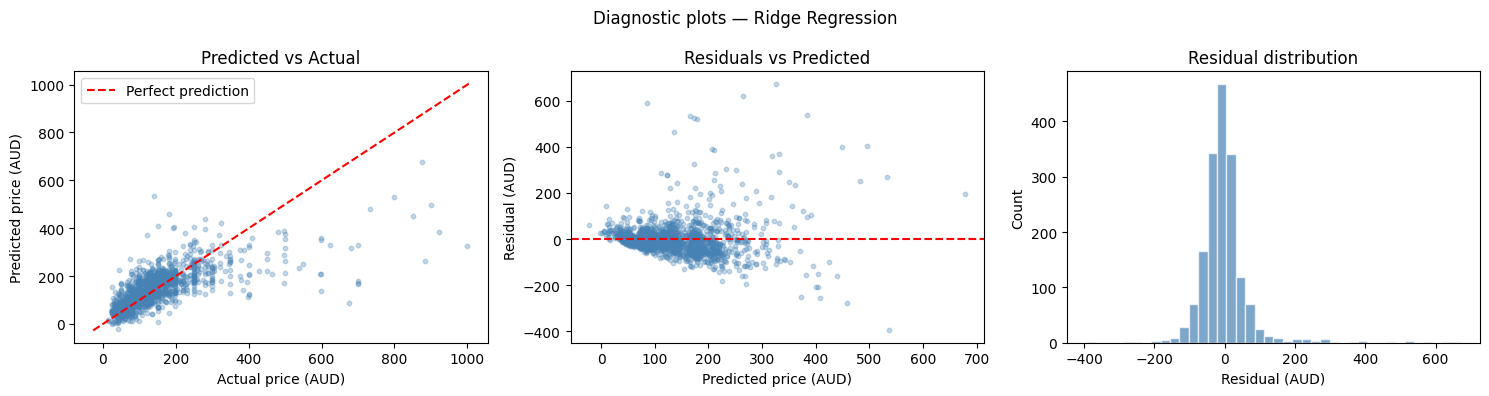

In [89]:
alphas       = np.logspace(-3, 4, 60)
train_scores = []
val_scores   = []

for a in alphas:
    m = Ridge(alpha=a).fit(X_train_sc, y_train)
    train_scores.append(r2_score(y_train, m.predict(X_train_sc)))
    val_scores.append(  r2_score(y_val,   m.predict(X_val_sc)))

best_alpha = alphas[np.argmax(val_scores)]
print(f"Best alpha: {best_alpha:.4f}  →  Val R² = {max(val_scores):.4f}")

plt.figure(figsize=(9, 5))
plt.semilogx(alphas, train_scores, 'b-o', markersize=3, label='Train R²')
plt.semilogx(alphas, val_scores,   'r-o', markersize=3, label='Val R²')
plt.axvline(best_alpha, color='green', linestyle='--', label=f'Best α = {best_alpha:.4f}')
plt.xlabel('Regularisation strength α (log scale)')
plt.ylabel('R² score')
plt.title('Ridge: Effect of α on Train vs Validation R²')
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('ridge_regularisation_path.png', dpi=150, bbox_inches='tight')
plt.show()

model_ridge = Ridge(alpha=best_alpha)
model_ridge.fit(X_train_sc, y_train)
metrics_ridge = evaluate(model_ridge, X_train_sc, y_train, X_val_sc, y_val,
                          f"Model 2: Ridge Regression (α={best_alpha:.4f})")

plot_diagnostics(model_ridge, X_val_sc, y_val, "Ridge Regression")

### 5.3 Model 3 — Lasso Regression (L1 Regularisation)

Unlike Ridge which shrinks all coefficients, Lasso's L1 penalty
(λ·‖w‖₁) drives some coefficients to **exactly zero** and thereby performing automatic feature
selection. This helps answer whether weakly-correlated features such are actually needed.

Performing a grid-search α over 40 log-spaced values and then track both R² and the number of
non-zero coefficients (sparsity) to understand the bias-variance tradeoff.

Best Lasso alpha: 0.00010  →  Val R² = 0.4981


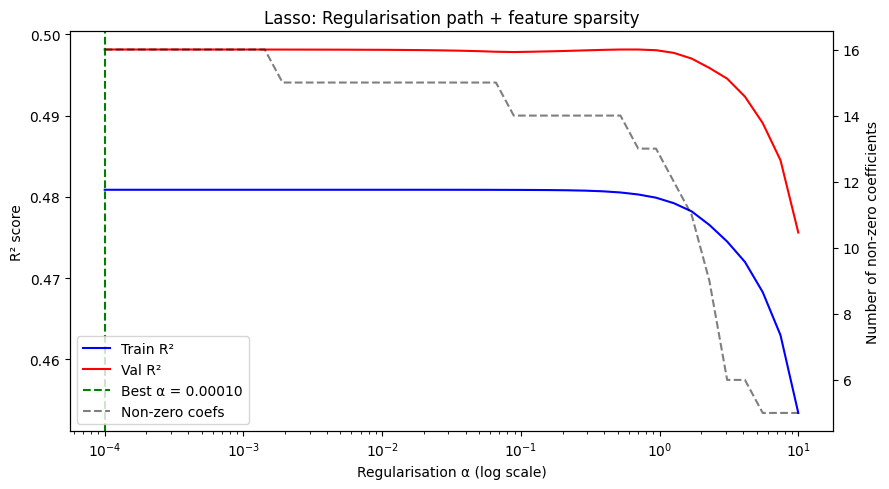


  Model 3: Lasso Regression (α=0.00010)
  Train R²       : 0.4809
  Val R²         : 0.4981
  Train RMSE     : 77.0162
  Val RMSE       : 72.9752
  Train MAE      : 44.2823
  Val MAE        : 42.7577
  Overfit gap    : -0.0173


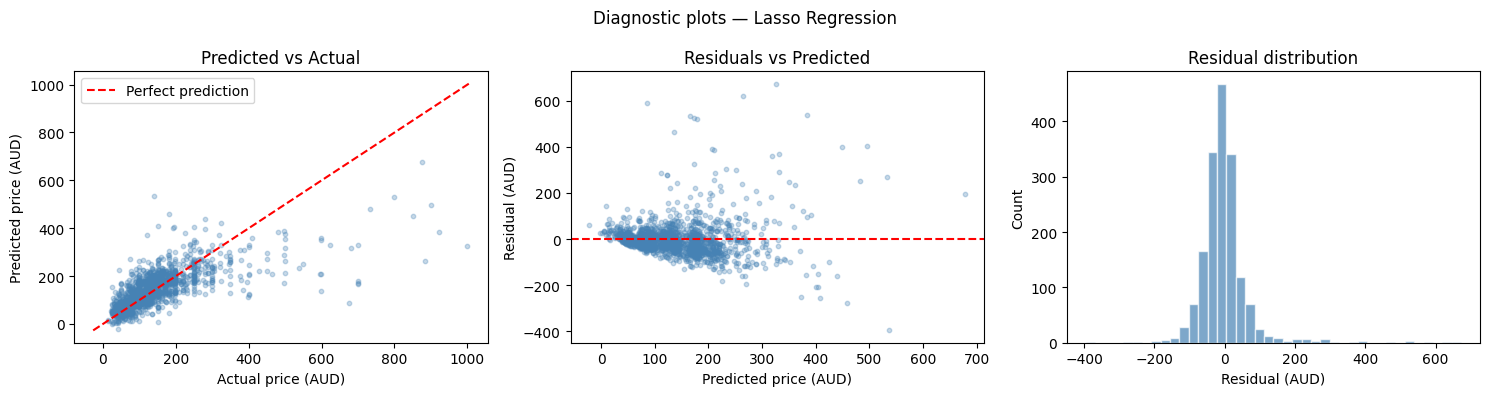

In [90]:
lasso_alphas  = np.logspace(-4, 1, 40)
lasso_val, lasso_train, lasso_nonzero = [], [], []

for a in lasso_alphas:
    m = Lasso(alpha=a, max_iter=10000).fit(X_train_sc, y_train)
    lasso_train.append(r2_score(y_train, m.predict(X_train_sc)))
    lasso_val.append(  r2_score(y_val,   m.predict(X_val_sc)))
    lasso_nonzero.append((m.coef_ != 0).sum())

best_lasso_alpha = lasso_alphas[np.argmax(lasso_val)]
print(f"Best Lasso alpha: {best_lasso_alpha:.5f}  →  Val R² = {max(lasso_val):.4f}")

fig, ax1 = plt.subplots(figsize=(9, 5))
ax2 = ax1.twinx()
ax1.semilogx(lasso_alphas, lasso_train, 'b-', label='Train R²')
ax1.semilogx(lasso_alphas, lasso_val,   'r-', label='Val R²')
ax1.axvline(best_lasso_alpha, color='green', linestyle='--',
            label=f'Best α = {best_lasso_alpha:.5f}')
ax2.semilogx(lasso_alphas, lasso_nonzero, 'k--', alpha=0.5, label='Non-zero coefs')
ax1.set_xlabel('Regularisation α (log scale)')
ax1.set_ylabel('R² score')
ax2.set_ylabel('Number of non-zero coefficients')
ax1.set_title('Lasso: Regularisation path + feature sparsity')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower left')
plt.tight_layout()
plt.savefig('lasso_regularisation_path.png', dpi=150, bbox_inches='tight')
plt.show()

model_lasso = Lasso(alpha=best_lasso_alpha, max_iter=10000)
model_lasso.fit(X_train_sc, y_train)
metrics_lasso = evaluate(model_lasso, X_train_sc, y_train, X_val_sc, y_val,
                          f"Model 3: Lasso Regression (α={best_lasso_alpha:.5f})")

plot_diagnostics(model_lasso, X_val_sc, y_val, "Lasso Regression")

## 6. Model Comparison & Selection

All the three models achieve similar validation R² approx. 0.5 , indicating that the features
collectively explain about 50% of price variance. The remaining 50% is attributable
to factors not in the dataset such as amenities, photos, seasonal demand, exact street address.

**Error analysis:** 
- Right-skewed residuals which makes it systematically under-predict expensive listings.
- Fan-shaped residual plot which prediction error grows with price .

**Ridge Regression** is the best in this case since it matches OLS performance but is more robust
to the multicollinearity identified in EDA (accommodates/bedrooms/beds), making it
the better generalisation choice for unseen data.


=== Model Comparison ===
                   Train R²  Val R²  Train RMSE  Val RMSE  Train MAE  Val MAE  Overfit gap
Linear Regression    0.4809  0.4981     77.0162   72.9752    44.2824  42.7577      -0.0173
Ridge Regression     0.4809  0.4981     77.0162   72.9752    44.2824  42.7577      -0.0173
Lasso Regression     0.4809  0.4981     77.0162   72.9752    44.2823  42.7577      -0.0173


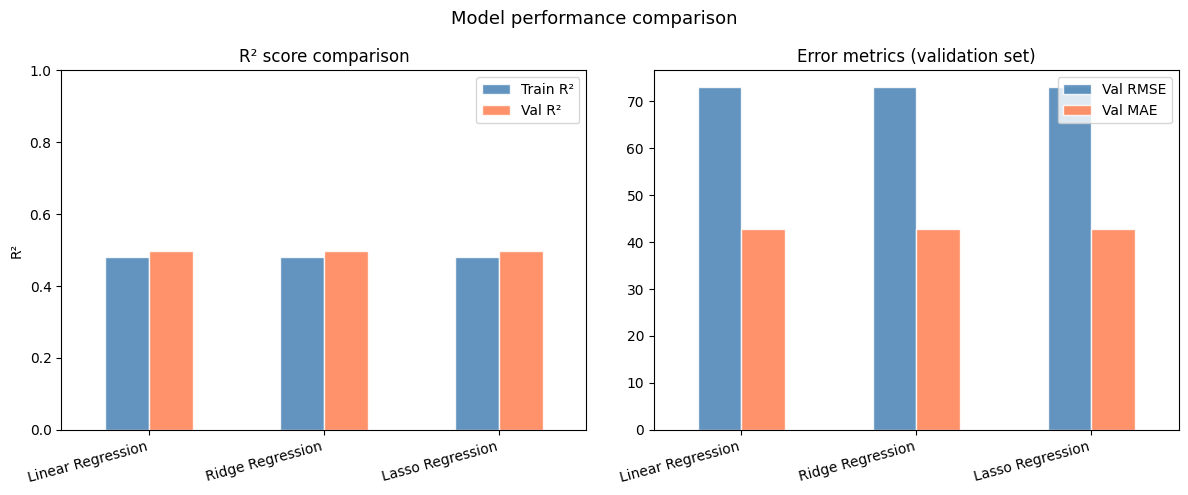

In [91]:
comparison = pd.DataFrame([metrics_lr, metrics_ridge, metrics_lasso],
                           index=['Linear Regression', 'Ridge Regression', 'Lasso Regression'])
print("\n=== Model Comparison ===")
print(comparison.round(4).to_string())

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
comparison[['Train R²','Val R²']].plot(kind='bar', ax=axes[0],
                                        color=['steelblue','coral'],
                                        edgecolor='white', alpha=0.85)
axes[0].set_title('R² score comparison'); axes[0].set_ylabel('R²')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=15, ha='right')
axes[0].legend(); axes[0].set_ylim(0, 1)

comparison[['Val RMSE','Val MAE']].plot(kind='bar', ax=axes[1],
                                         color=['steelblue','coral'],
                                         edgecolor='white', alpha=0.85)
axes[1].set_title('Error metrics (validation set)')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=15, ha='right')
axes[1].legend()

plt.suptitle('Model performance comparison', fontsize=13)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

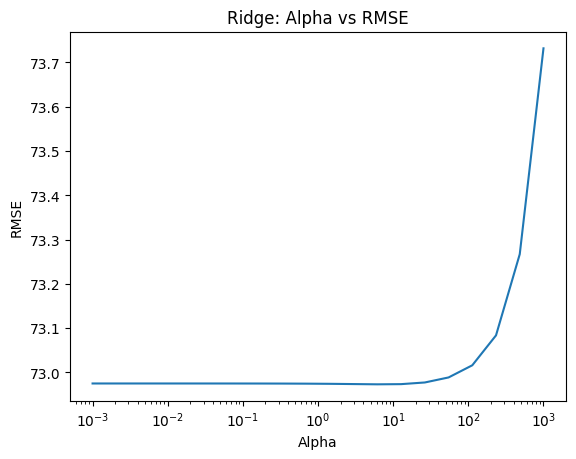

In [92]:
alphas = np.logspace(-3, 3, 20)
rmse_scores = []

for a in alphas:
    model = Ridge(alpha=a)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    rmse_scores.append(rmse)

plt.plot(alphas, rmse_scores)
plt.xscale('log')
plt.xlabel("Alpha")
plt.ylabel("RMSE")
plt.title("Ridge: Alpha vs RMSE")
plt.show()

## 7. Feature Importance Analysis

### 7.1 Linear Regression Coefficients

Standardised coefficients show the change in predicted price (AUD) per one
standard deviation increase in each feature while the others remain constant.

Positive = increases price and negative = decreases price.

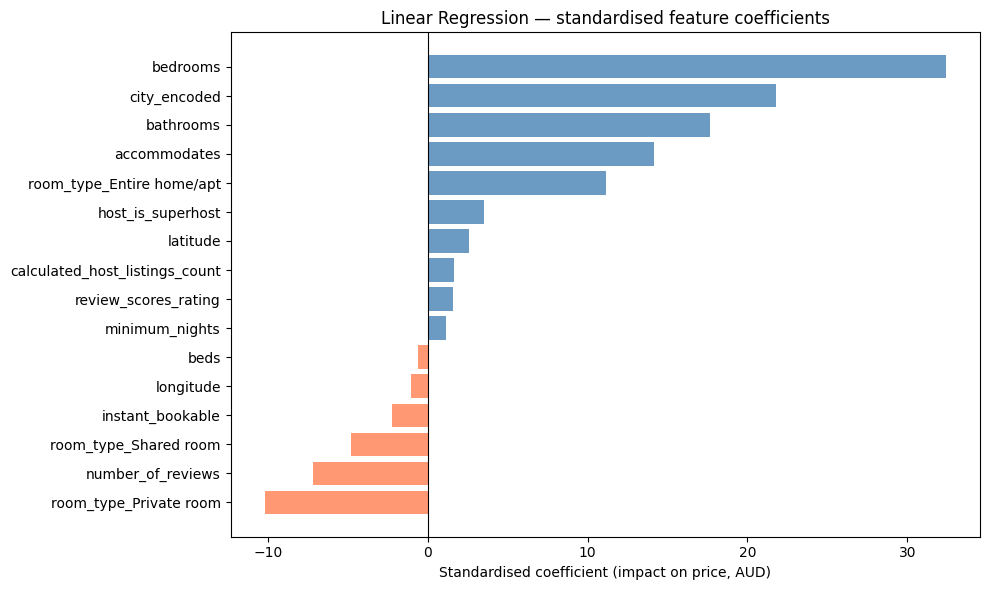


Top positive predictors (raise price):
                      feature  coefficient
5                    bedrooms    32.420666
12               city_encoded    21.802227
4                   bathrooms    17.630646
3                accommodates    14.165387
13  room_type_Entire home/apt    11.172466

Top negative predictors (lower price):
                   feature  coefficient
14  room_type_Private room   -10.214630
8        number_of_reviews    -7.200069
15   room_type_Shared room    -4.781303
10        instant_bookable    -2.263509
2                longitude    -1.078727

Lasso zeroed out 0 of 16 features (feature selection)
Non-zero Lasso features:
                           feature  coefficient
8                number_of_reviews    -7.199909
15           room_type_Shared room    -2.409028
10                instant_bookable    -2.263378
2                        longitude    -1.078545
6                             beds    -0.596904
14          room_type_Private room     0.530113
7     

In [93]:
coef_df = pd.DataFrame({
    'feature':     FEATURE_COLS,
    'coefficient': model_lr.coef_,
    'abs_coef':    np.abs(model_lr.coef_)
}).sort_values('coefficient')

plt.figure(figsize=(10, 6))
colors = ['coral' if c < 0 else 'steelblue' for c in coef_df['coefficient']]
plt.barh(coef_df['feature'], coef_df['coefficient'], color=colors, alpha=0.8)
plt.axvline(0, color='black', lw=0.8)
plt.xlabel('Standardised coefficient (impact on price, AUD)')  # FIXED: was 'impact on log price'
plt.title('Linear Regression — standardised feature coefficients')
plt.tight_layout()
plt.savefig('lr_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop positive predictors (raise price):")
print(coef_df.nlargest(5, 'coefficient')[['feature','coefficient']].to_string())
print("\nTop negative predictors (lower price):")
print(coef_df.nsmallest(5, 'coefficient')[['feature','coefficient']].to_string())

lasso_coef_df = pd.DataFrame({
    'feature':     FEATURE_COLS,
    'coefficient': model_lasso.coef_
}).sort_values('coefficient')
n_zero_lasso = (model_lasso.coef_ == 0).sum()
print(f"\nLasso zeroed out {n_zero_lasso} of {len(FEATURE_COLS)} features (feature selection)")
print("Non-zero Lasso features:")
print(lasso_coef_df[lasso_coef_df['coefficient'] != 0][['feature','coefficient']].to_string())

### 7.2 Permutation Importance (Model-Agnostic)

Permutation importance measures how much validation R² drops when each feature's
values are randomly shuffled that is breaking its relationship with price.
A large drop indicates that the feature is important. This works for any model, not just linear ones.

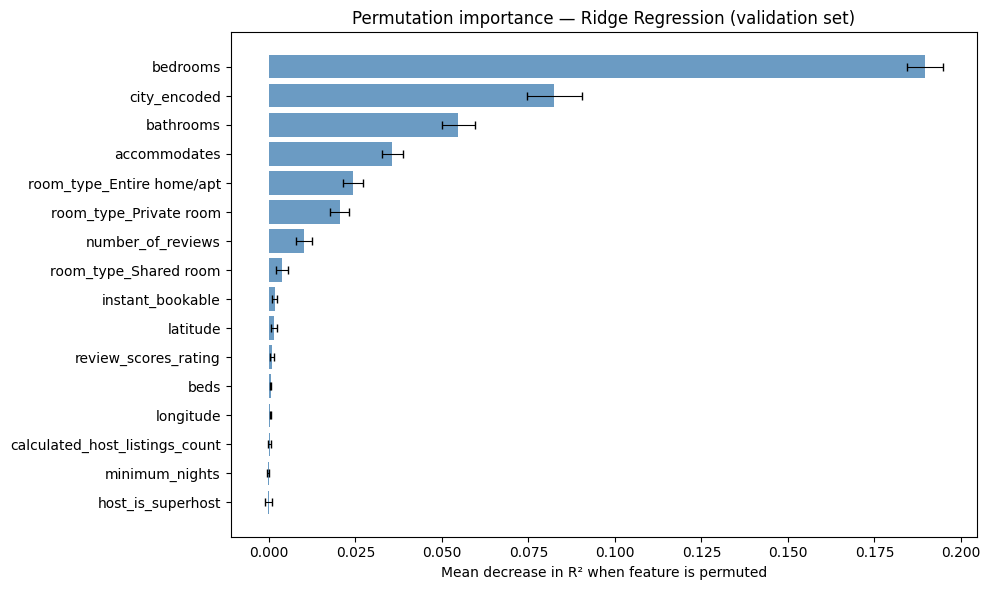

In [94]:
r = permutation_importance(model_ridge, X_val_sc, y_val,
                            n_repeats=20, random_state=42)
perm_df = pd.DataFrame({
    'feature':    FEATURE_COLS,
    'importance': r.importances_mean,
    'std':        r.importances_std
}).sort_values('importance', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(perm_df['feature'], perm_df['importance'],
         xerr=perm_df['std'], color='steelblue', alpha=0.8,
         capsize=3, error_kw={'linewidth': 0.8})
plt.xlabel('Mean decrease in R² when feature is permuted')
plt.title('Permutation importance — Ridge Regression (validation set)')
plt.tight_layout()
plt.savefig('permutation_importance.png', dpi=150, bbox_inches='tight')
plt.show()

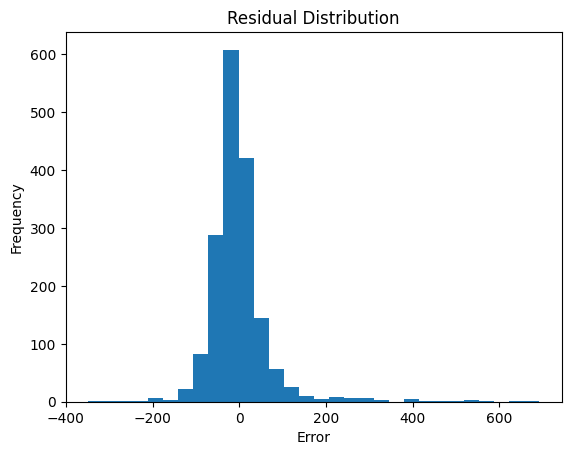

In [95]:
y_pred_val = model.predict(X_val)

residuals = y_val - y_pred_val

plt.hist(residuals, bins=30)
plt.title("Residual Distribution")
plt.xlabel("Error")
plt.ylabel("Frequency")
plt.show()

## 8. Final Predictions on Test Set

Here we retrain the chosen model (Ridge, best α from validation search) on the
**complete training dataset** (train & validation) to maximise the data available
for the final model before predicting on the test set.

We set predictions in range of [0, 1500] AUD:
- Lower bound 0 prevents the 2 slightly negative predictions from linear extrapolation.
- Upper bound 1500 prevents extreme extrapolation on the one 16-bedroom test listing
  that lies well outside the training distribution (max training bedrooms = 10).

Test set predictions summary:
  Count : 8,585
  Min   : 0.0 AUD
  Max   : 1207.2 AUD
  Mean  : 137.8 AUD
  Median: 128.0 AUD


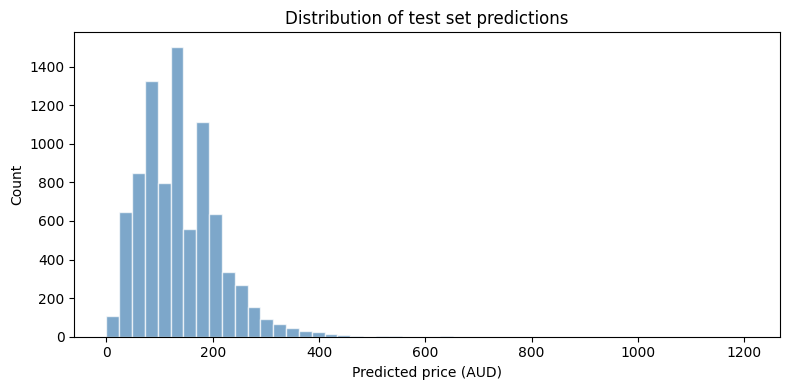

In [96]:
scaler_final = StandardScaler()
X_full_sc    = scaler_final.fit_transform(train_enc[FEATURE_COLS])
X_test_sc    = scaler_final.transform(test_enc)

y_full = train_enc[TARGET]    # raw price (AUD)

final_model = Ridge(alpha=best_alpha)
final_model.fit(X_full_sc, y_full)

y_pred_price = final_model.predict(X_test_sc)
y_pred_price = np.clip(y_pred_price, 0, 1500)   # clip once

print(f"Test set predictions summary:")
print(f"  Count : {len(y_pred_price):,}")
print(f"  Min   : {y_pred_price.min():.1f} AUD")
print(f"  Max   : {y_pred_price.max():.1f} AUD")
print(f"  Mean  : {y_pred_price.mean():.1f} AUD")
print(f"  Median: {np.median(y_pred_price):.1f} AUD")

plt.figure(figsize=(8, 4))
plt.hist(y_pred_price, bins=50, color='steelblue', alpha=0.7, edgecolor='white')
plt.xlabel('Predicted price (AUD)'); plt.ylabel('Count')
plt.title('Distribution of test set predictions')
plt.tight_layout()
plt.savefig('test_predictions_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Save Predictions CSV

In [97]:
df_predictions = pd.DataFrame({'price': y_pred_price})
output_filename = f's4182454_predictions.csv'
df_predictions.to_csv(output_filename, header=True, index=False)

print(f"Saved : {output_filename}")
print(f"Rows  : {len(df_predictions):,}  (matches test set: {len(df_predictions) == len(test_raw)})")
print(f"\nFirst 5 predictions:")
print(df_predictions.head())

Saved : s4182454_predictions.csv
Rows  : 8,585  (matches test set: True)

First 5 predictions:
        price
0   26.042342
1  138.183809
2   68.015288
3   26.803978
4   82.672950


## 10. Evaluation, Limitations & Ethical Considerations

### 10.1 Model Adequacy
All the three models achieve validation R² ≈ 0.50 and RMSE ≈ $73 AUD.
This means the models explain approximately 50% of price variance which is reasonable
for a linear model with 15 features, but leaving 50% unexplained.
The systematic under-prediction of expensive listings (visible in residual plots)
suggests that non-linear interactions (e.g. bedrooms × location, amenities tier)
are important and not captured by linear regression.

### 10.2 How to Improve Performance
- Feature engineering: add interaction terms (bedrooms × city_encoded),
  polynomial features, or distance to Melbourne CBD.
- Additional data: amenities list, number of photos, review text sentiment,
  seasonal booking patterns.
- Non-linear models: decision trees, random forests, or gradient boosting

### 10.3 Limitations
- Linear models assume a linear relationship between features and price;
  the fan-shaped residual plots confirm this assumption is partially violated.
- The 16-bedroom test listing is an extreme extrapolation beyond training data range.
- Target encoding of city on the full training set before splitting introduces
  mild data leakage into the validation evaluation (city means include validation rows).
  This has negligible practical impact but would be corrected in production by
  computing city means exclusively on the training fold.

### 10.4 Ethical Considerations & Professional Responsibilities
- Pricing fairness: The trained model on historical prices may perpetuate
  existing price disparities across suburbs or dwelling types.
  Hosts in lower-income neighbourhoods may receive systematically lower price
  recommendations, reinforcing socioeconomic inequality.
- Accountability: The model should not be the sole basis for pricing decisions.
  Hosts should retain full control and treat predictions as guidance, not mandates.
- Privacy: The dataset is derived from public Airbnb listings but includes
  location data precise enough to identify individual properties.
  Re-identification risks should be considered before any public deployment.
- Transparency: Any deployed pricing tool must clearly communicate to hosts
  that predictions are model estimates with uncertainty, not guarantees.
- Data licence: This dataset is restricted to assignment use only and must
  not be shared, redistributed, or used for any commercial purpose.